# **Project Name**    - **Amazon Prime TV Shows and Movies**



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

Amazon Prime Video is one of the leading streaming platforms, offering a vast collection of TV shows and movies across various genres, languages, and regions. The aim of this Exploratory Data Analysis (EDA) project is to analyze Amazon Prime’s content library to uncover key insights about trends, genres, content distribution, and other patterns that shape the platform’s offerings. By examining the dataset, we can gain a deeper understanding of content diversity, regional preferences, and factors that influence viewer engagement.

# **GitHub Link -**

(https://github.com/himanshi742006/Amazon-Prime-EDA-Himanshi/blob/main/Amazon_Prime_TV_Shows_and_Movies_Himanshi.ipynb)

# **Problem Statement**


**Problem Statement:**

Create a Exploratory Data Analysis project to get the important insinghts to help Amazon Prime Video for managing their content library and viewer satisfaction factor.

#### **Define Your Business Objective?**

**Business Objective:**

To identify key insights and trends from Amazon Prime Video's content data to drive data-informed decisions that enhance content acquisition, production, and personalized recommendations, ultimately improving viewer engagement and satisfaction.

# **General Guidelines** : -  

*   List item
*   List item



1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

I have got two datasets, so at first i have to load both of them, Then i will merge them in a single DataFrame.

In [ ]:
# Load Dataset
movies_df = pd.read_csv('/content/titles.csv.zip')
characters_df = pd.read_csv('/content/credits.csv.zip')

### Dataset First View

In [ ]:
# Fetch Movies Data
movies_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [ ]:
# Fetch Character Data
characters_df.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
movies_df.shape

(9871, 15)

In [ ]:
characters_df.shape

(124235, 5)

### Dataset Information

In [ ]:
# Dataset Info
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [ ]:
characters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
movies_df.duplicated().sum()

np.int64(3)

In [ ]:
characters_df.duplicated().sum()

np.int64(56)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
movies_df.isnull().sum()

,0
id,0
title,0
type,0
description,119
release_year,0
age_certification,6487
runtime,0
genres,0
production_countries,0
seasons,8514


In [ ]:
characters_df.isnull().sum()

,0
person_id,0
id,0
name,0
character,16287
role,0


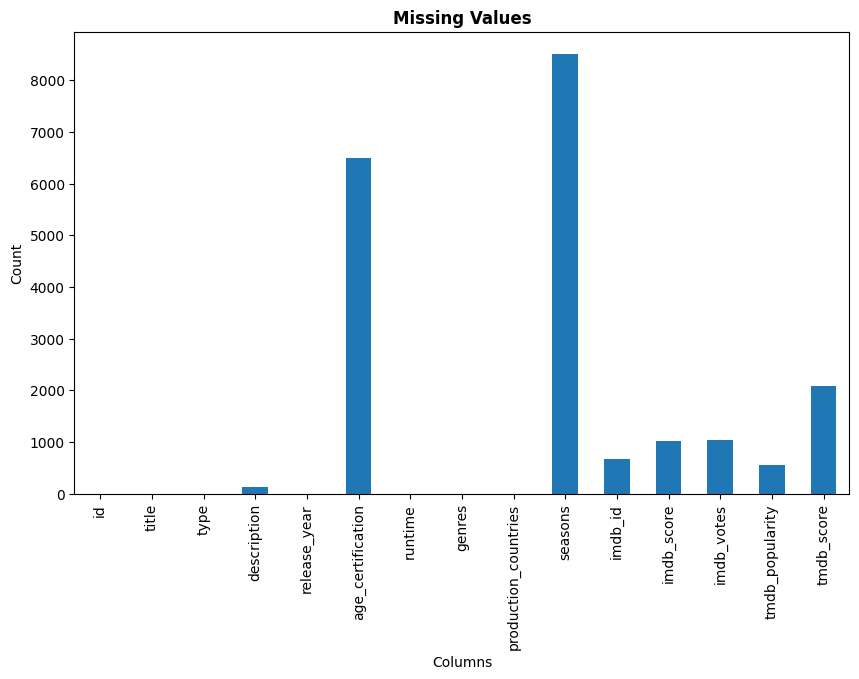

In [ ]:
# Visualizing the missing values
movies_df.isnull().sum().plot(kind='bar', figsize=(10, 6))
plt.title('Missing Values', fontweight = 'bold')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.show()

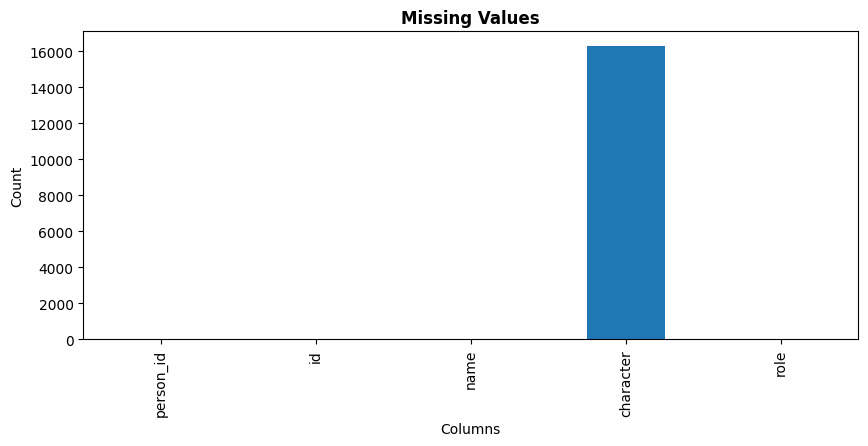

In [ ]:
# Visualization
characters_df.isnull().sum().plot(kind='bar', figsize=(10, 4))
plt.title('Missing Values', fontweight = 'bold')
plt.xlabel('Columns')
plt.ylabel('Count')
plt.show()



## What did you know about your dataset?

1.   **Source:**


*   The file path for movies_df Shows dataset is: `/content/titles.csv.zip`
*   The file path for characters_df dataset is: `/content/credits.csv.zip`

2. **Content:**


*   The movies_df dataset contains information about movies and TV shows available on Amazon Prime Video.
  *   It includes various attributes such as:
      - `id`: Unique identifier for each title.
      - `title`: Title of the movie or TV show.
      - `type`: Whether it's a `MOVIE` or `SHOW`.
      - `description`: Brief description of the content
      - `release_year`: Year of release.
      - `age_certification`: Age rating (e.g., PG-13, R, TV-G).
      - `runtime`: Duration in minutes.
      - `genres`: List of genres associated with the content.
      - `production_countries`: List of countries where the content was produced.
      - `seasons`: Number of TV Shows seasons(It appliesm to `type`-SHOW only
      - `imdb_id`: IMDB identifier
      - `imdb_score`: IMDb rating
      - `imdb_votes`: Number of IMDb votes
      - `tmdb_popularity`: TMDB popularity score
      - `tmdb_score`: TMDB rating Number of IMDb votes
      - `tmdb_popularity`: TMDB popularity score.
      - `tmdb_score`: TMDB rating.
*   The characters_df dataset contains the information about the actors and their roles, which they had played for the Movies or TV show available on Amazon Prime Video
  *   It includesn some attributes as:
      - `person_id` : Unique identifier for each person involved in the title
      - `id` : Unique identifier for the title (movie or TV show)
      - `name` : Name of the person involved (actor, director, etc.)
      - `character` : Name of the character played by the person (if applicable)
      - `role` : Role of the person in the title (e.g., 'ACTOR', 'DIRECTOR')
3.   **Size and Shape:**
*   The original movies_df dataset had 9871 rows and 15 columns.
*   After removing duplicates and handling null values, the dataset shape changed. The code indicates `movies_df.shape` gives the final size.
*   The original characters_df dataset had 124235 rows and 5 columns.
*   After removing duplicates and handling null values, the dataset shape changed. The code indicates `characters_df.shape` gives the final size.

 **In summary, the dataset provides a comprehensive collection of details about movies and TV shows on Amazon Prime Video. It will undergone data cleaning and preparation for further analysis and visualization.**



*   The `characters_df` dataset contains cast & crew information linked to each title:
    - `person_id`: Unique identifier for each person
    - `id`: Title identifier (foreign key to `movies_df`)
    - `name`: Name of the actor/director
    - `character`: Character played (applicable to actors)
    - `role`: ACTOR or DIRECTOR

3.   **Size:**
*   `movies_df` (titles.csv): 9,871 rows × 15 columns
*   `characters_df` (credits.csv): 124,235 rows × 5 columns

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
movies_df.columns.to_list()

['id',
 'title',
 'type',
 'description',
 'release_year',
 'age_certification',
 'runtime',
 'genres',
 'production_countries',
 'seasons',
 'imdb_id',
 'imdb_score',
 'imdb_votes',
 'tmdb_popularity',
 'tmdb_score']

In [ ]:
characters_df.columns.to_list()

['person_id', 'id', 'name', 'character', 'role']

In [ ]:
# Dataset Describe
movies_df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


### Variables Description

**Movies and Tv shows Dataframe**

| Variable | Description |
|---|---|
| id | Unique identifier for each title |
| title | Title of the movie or TV show |
| type | Whether it's a `MOVIE` or `SHOW` |
| description | Brief description of the content |
| release_year | Year of release |
| age_certification | Age rating (e.g., PG-13, R, TV-G) |
| runtime | Duration in minutes |
| genres | List of genres associated with the content |
| production_countries | List of countries where the content was produced |
| seasons | Number of seasons (applies to `SHOW` type only) |
| imdb_id | IMDb identifier |
| imdb_score | IMDb rating |
| imdb_votes | Number of IMDb votes |
| tmdb_popularity | TMDB popularity score |
| tmdb_score | TMDB rating |

**Actors and Characters Dataframe**

| Variable | Description |
|---|---|
| person_id | Unique identifier for each person involved in the title |
| id | Unique identifier for the title (movie or TV show) |
| name | Name of the person involved (actor, director, etc.) |
| character | Name of the character played by the person (if applicable) |
| role | Role of the person in the title (e.g., 'ACTOR', 'DIRECTOR') |

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
unique_values = movies_df.nunique().reset_index()
unique_values.columns = ['Column', 'Unique Values']
unique_values

,Column,Unique Values
0,id,9868
1,title,9737
2,type,2
3,description,9734
4,release_year,110
5,age_certification,11
6,runtime,207
7,genres,2028
8,production_countries,497
9,seasons,32


In [ ]:
movies_unique = characters_df.nunique().reset_index()
movies_unique.columns = ['Variable', 'Unique Values']
movies_unique

,Variable,Unique Values
0,person_id,80508
1,id,8861
2,name,79758
3,character,71097
4,role,2


## 3. ***Data Wrangling***

### Data Wrangling Code

Delete the duplicte values


In [ ]:
# check for duplicate values
movies_df.duplicated().sum()

np.int64(3)

In [ ]:
characters_df.duplicated().sum()

np.int64(56)

In [ ]:
# Delete duplicate values
movies_df.drop_duplicates(inplace = True)
characters_df.drop_duplicates(inplace = True)

In [ ]:
# Merge the titles and credits datasets
merged_df = pd.merge(movies_df, characters_df, on='id', how='inner')
merged_df.shape

(124179, 19)

In [ ]:
# Drop the 'imdb_id' column as it is not required for EDA
merged_df.drop(columns='imdb_id', inplace=True)

In [ ]:
# Create a title-level dataset for analysis
movies_tv_shows_df = merged_df.drop_duplicates('id').copy()

In [ ]:
# Check the total number of rows in the title-level dataset
print("Total rows:", len(movies_tv_shows_df))

# Check the number of unique title IDs
print("Unique titles:", movies_tv_shows_df['id'].nunique())

Total rows: 8861
Unique titles: 8861


# **Check Distribution**

IMDb Score

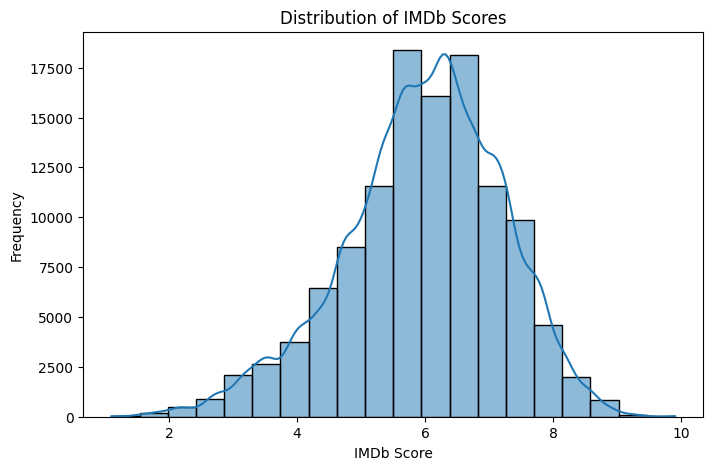

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data=merged_df, x='imdb_score', bins=20, kde=True)

plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Frequency')

plt.show()

IMDb Votes

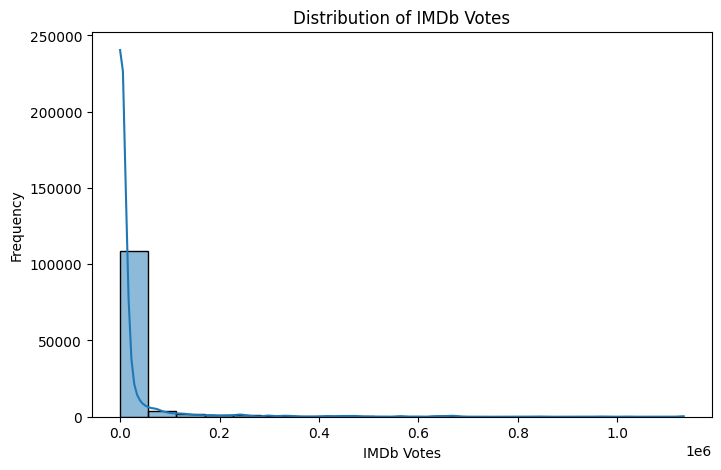

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data=merged_df, x='imdb_votes', bins=20, kde=True)

plt.title('Distribution of IMDb Votes')
plt.xlabel('IMDb Votes')
plt.ylabel('Frequency')

plt.show()

TMDB Score

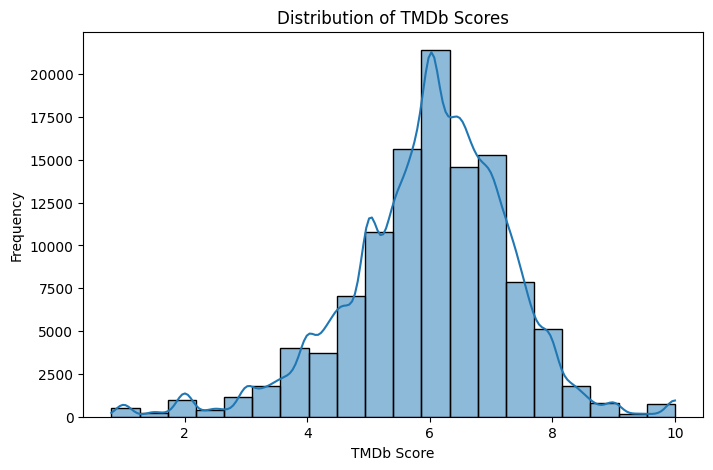

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=merged_df, x='tmdb_score', bins=20, kde=True)
plt.title('Distribution of TMDb Scores')
plt.xlabel('TMDb Score')
plt.ylabel('Frequency')
plt.show()

TMDb Popularity

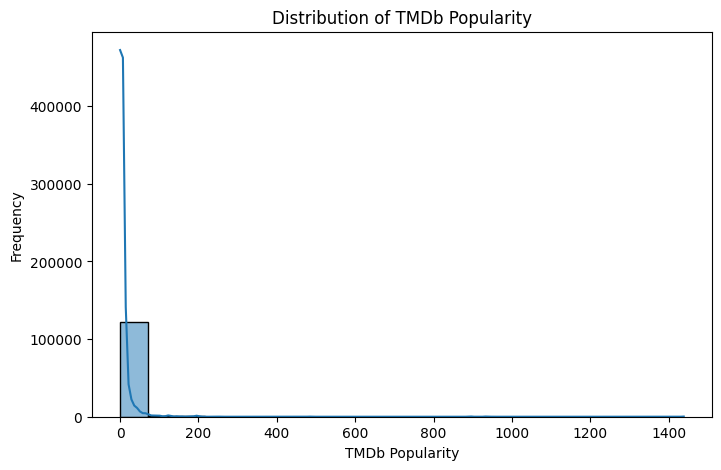

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=merged_df, x='tmdb_popularity', bins=20, kde=True)
plt.title('Distribution of TMDb Popularity')
plt.xlabel('TMDb Popularity')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Missing values count and percentage
missing_values = pd.DataFrame({
    'Missing Values': merged_df.isnull().sum(),
    'Percentage (%)': (merged_df.isnull().sum() / len(merged_df) * 100).round(2)
})

missing_values

,Missing Values,Percentage (%)
id,0,0.00
title,0,0.00
type,0,0.00
description,91,0.07
release_year,0,0.00
age_certification,67472,54.33
runtime,0,0.00
genres,0,0.00
production_countries,0,0.00
seasons,116026,93.43


Description null value handling

In [ ]:
# Remove rows with missing descriptions
merged_df.dropna(subset=['description'], inplace=True)

Age Certification null value handling

In [ ]:
# Get the most frequent value from the DataFrame
most_frequent_value = merged_df['age_certification'].value_counts().idxmax()

print(most_frequent_value)

R


In [ ]:
# Fill missing values with most_frequent_value
merged_df['age_certification'] = merged_df['age_certification'].fillna(most_frequent_value)

In [ ]:
# check all the unique values of age restriction column
merged_df['age_certification'].unique()

array(['TV-PG', 'R', 'PG', 'G', 'PG-13', 'TV-G', 'TV-Y', 'TV-14', 'NC-17',
       'TV-Y7', 'TV-MA'], dtype=object)

Imdb Score null value handling

In [ ]:
# Fill missing values in the IMDb score column using the median
merged_df['imdb_score'] = merged_df['imdb_score'].fillna(merged_df['imdb_score'].median())

Imdb Votes null value handling

In [ ]:
# Fill missing values in the Imdb Votes column using the median
merged_df['imdb_votes']=merged_df['imdb_votes'].fillna(merged_df['imdb_votes'].median())

TMDB Plopularity null value handling

In [ ]:
# Fill missing values in the TMDB Plopularity column using the median
merged_df['tmdb_popularity']=merged_df['tmdb_popularity'].fillna(merged_df['tmdb_popularity'].median())

TMDB Score null value handling

In [ ]:
# Fill missing values in the TMDB Score column using the median
merged_df['tmdb_score']=merged_df['tmdb_score'].fillna(merged_df['tmdb_score'].median())

Handle empty values in the production countries column


In [ ]:
# Handle empty values in the production_countries column
merged_df['production_countries'] = merged_df['production_countries'].replace('[]', 'Unknown')

In [ ]:
merged_df.shape

(124088, 18)

In [ ]:
# final checklist for the null values
merged_df.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
seasons,115987


In [ ]:
# Check the number of unique values in each column
for column in merged_df.columns:
    print(f"{column}: {merged_df[column].nunique()}")

id: 8842
title: 8729
type: 2
description: 8833
release_year: 110
age_certification: 11
runtime: 204
genres: 1965
production_countries: 482
seasons: 30
imdb_score: 85
imdb_votes: 3623
tmdb_popularity: 5263
tmdb_score: 88
person_id: 80447
name: 79700
character: 71070
role: 2


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124088 entries, 0 to 124178
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    124088 non-null  object 
 1   title                 124088 non-null  object 
 2   type                  124088 non-null  object 
 3   description           124088 non-null  object 
 4   release_year          124088 non-null  int64  
 5   age_certification     124088 non-null  object 
 6   runtime               124088 non-null  int64  
 7   genres                124088 non-null  object 
 8   production_countries  124088 non-null  object 
 9   seasons               8101 non-null    float64
 10  imdb_score            124088 non-null  float64
 11  imdb_votes            124088 non-null  float64
 12  tmdb_popularity       124088 non-null  float64
 13  tmdb_score            124088 non-null  float64
 14  person_id             124088 non-null  int64  
 15  name 

In [ ]:
merged_df.shape

(124088, 18)

### What all manipulations have you done and insights you found?

**Data Manipulations**:
1. Handling Duplicate Values

Checked both `movies_df` and `characters_df` for duplicate records.

Removed duplicate rows from both datasets using `drop_duplicates()` before merging.

This ensured data consistency and prevented duplicate records from affecting the analysis.

2. Merging the Datasets

Merged `movies_df` and `characters_df` using an Inner Join on the **id** column.

Created a single dataset named `merged_df`, which contains both movie/TV show details and cast information.

3. Removing Unnecessary Column

Dropped the `imdb_id` column because it was not required for exploratory data analysis.

4. Handling Missing Values

Removed rows containing missing values in the `description` column.

Filled missing values in the age_certification column using the most frequent value (mode).

Checked the distribution of numerical columns before handling missing values.

Filled missing values in `imdb_score`, `imdb_votes`, `tmdb_score`, and `tmdb_popularity` using the median.

Left the missing values in the `character` and `seasons` columns unchanged because these missing values are meaningful and depend on the person's role or the content type.

5. Cleaning the Production Countries Column

Replaced empty list values (`[]`) in the `production_countries` column with "Unknown" to indicate unavailable information.

**Insights**:

The duplicate records were successfully removed, resulting in a cleaner and more reliable dataset.

Merging the two datasets created a comprehensive dataset containing both content details and cast information.

Only a few records had missing descriptions, so removing those rows had very little impact on the dataset.

More than half of the records in the `age_certification` column were missing, so the most frequent category was used to fill the missing values.

The distributions of `imdb_score`, `imdb_votes`, `tmdb_score`, and `tmdb_popularity` were analyzed using histograms and KDE plots before selecting the median for handling missing values.

The empty values in the `production_countries` column were replaced with `"Unknown"` instead of assigning an incorrect country.

The missing values in the `character` and `seasons` columns were kept unchanged because they represent valid missing information rather than data quality issues.

After completing these preprocessing steps, the dataset became cleaner, more consistent, and ready for exploratory data analysis and visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

Movies vs TV Shows Distribution

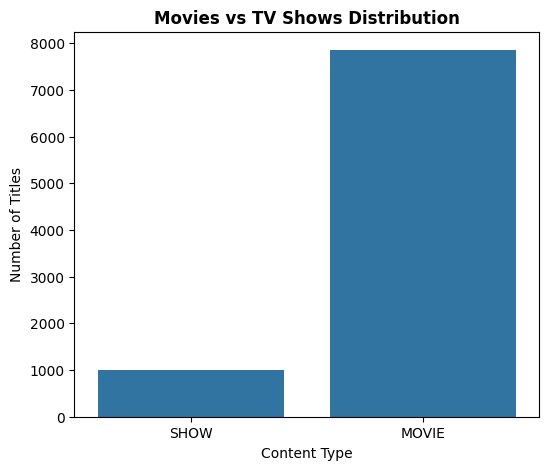

In [ ]:
# Chart - 1 visualization code

plt.figure(figsize=(6,5))

sns.countplot(data=movies_tv_shows_df, x='type')

plt.title('Movies vs TV Shows Distribution', fontweight = 'bold')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was selected to compare the number of Movies and TV Shows in the dataset. It provides a simple and clear comparison between the two content types and makes it easy to identify which type has a larger presence on the platform.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- Movies are significantly more numerous than TV Shows in the dataset.
- The dataset contains approximately 7,800+ Movies and around 1,000 TV Shows.
- This shows that the Amazon Prime content library is strongly dominated by Movies compared with TV Shows.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. This insight can help Amazon Prime Video understand the composition of its content library.

- Since Movies form the majority of the library, Amazon Prime can focus on improving movie recommendations and personalized movie discovery.
- The smaller number of TV Shows may indicate an opportunity to expand the TV Show catalog and attract users who prefer episodic content.
- Understanding the content mix can help in planning future content acquisition and production strategies.

**Possible Negative Impact**:

A heavy dependence on Movies may limit the platform's appeal to users who prefer TV Shows and long-term episodic content. Therefore, maintaining a balanced content portfolio could help improve user engagement and retention.

#### Chart - 2

Content Released Over the Years

In [ ]:
# Release year trends over time
release_year = movies_tv_shows_df.groupby('release_year').size().reset_index(name='count')

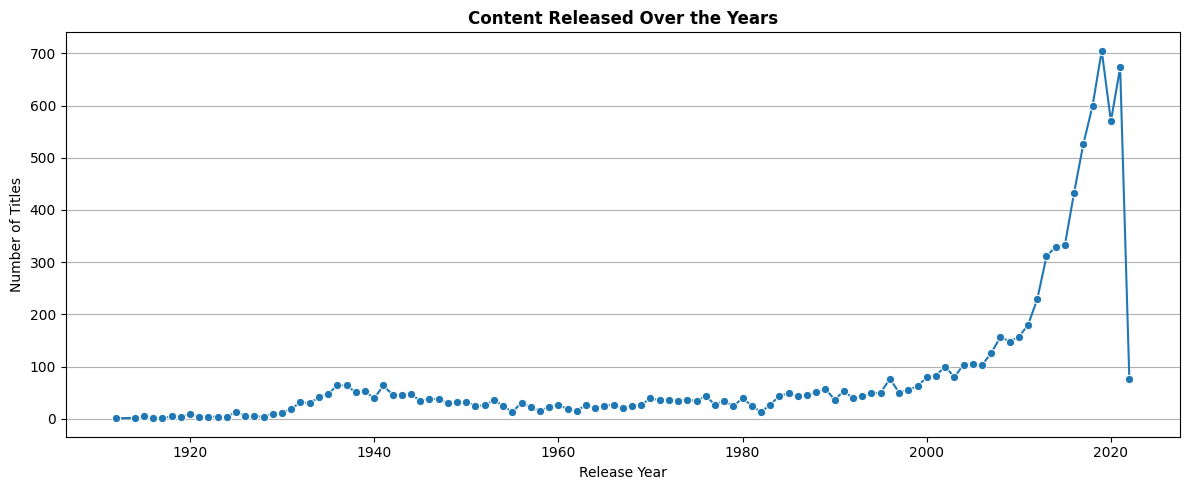

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(12,5))

sns.lineplot(data=release_year,
             x='release_year',
             y='count',
             marker='o')

plt.title('Content Released Over the Years', fontweight = 'bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(axis = 'y')
plt.tight_layout()

plt.show()

##### 1. Why did you pick the specific chart?

A line chart was selected to analyze how the number of Movies and TV Shows released has changed over the years. It is suitable for showing trends over time and makes increases, decreases, and major changes in content production easy to identify.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- The number of titles released per year was relatively low during the early years.
- Content releases gradually increased over time, with a noticeable increase after the 2000s.
- The number of releases increased sharply during the late 2010s.
- The highest number of titles was released around 2019, with approximately 700 titles.
- There is a noticeable fluctuation after 2019, with releases decreasing and then increasing again.
- The very low value for 2022 should not automatically be considered a real decline, as the dataset may contain incomplete records for the later years.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. The release trend can help Amazon Prime Video understand how content availability has changed over time and support future content planning.

- The strong growth in content releases in recent years indicates increasing content availability and investment in the streaming industry.
- Identifying periods with high content releases can help Amazon Prime plan future content acquisition and production.
- Understanding recent release trends can also help in planning content schedules and maintaining a consistent flow of new titles.

**Possible Negative Impact**:

A very rapid increase in the number of titles may make it difficult for users to discover relevant content. If content growth is not supported by effective recommendation and discovery systems, some titles may receive less visibility and engagement.

#### Chart - 3

Runtime comparison analysis by Type

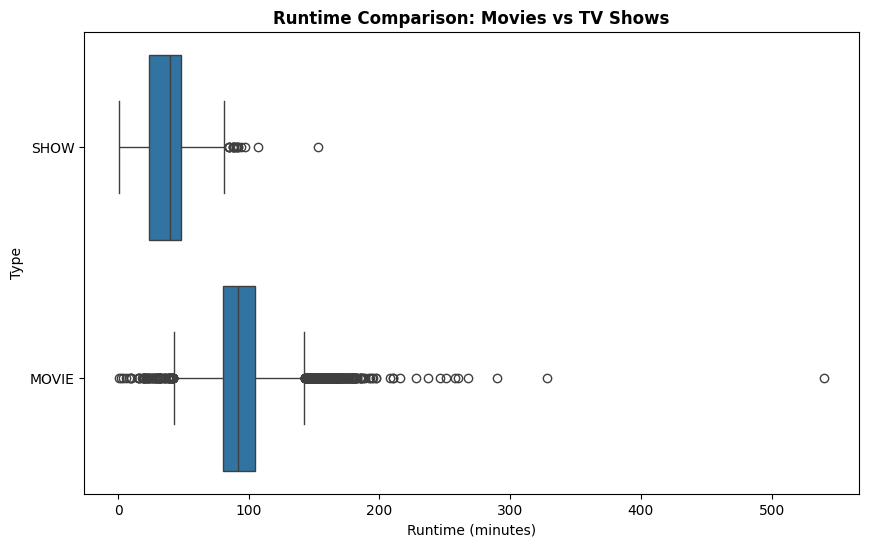

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(data = movies_tv_shows_df, x = 'runtime', y = 'type')

plt.title('Runtime Comparison: Movies vs TV Shows', fontweight = 'bold')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Type')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected to compare the runtime distribution of Movies and TV Shows. It helps identify the median runtime, variation, overall spread, and potential outliers for both content types.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- Movies generally have a higher runtime than TV Shows.
- The median runtime of Movies is around 90–100 minutes, while TV Shows have a lower median runtime.
- Movies show a wider range of runtime values and contain several outliers with unusually long runtimes.
- TV Shows have a comparatively narrower runtime distribution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. Runtime analysis can help Amazon Prime Video understand the typical viewing duration of different content types.

- Content Planning: Helps in planning and acquiring content with different runtime preferences.
- Recommendation Systems: Runtime can be considered when recommending content based on users' available viewing time.
- User Experience: Offering a mix of shorter and longer content can serve different viewer preferences.

**Possible Negative Impact**:

The presence of extremely long-runtime titles may appeal to only a smaller segment of viewers. However, having varied runtime options can help the platform serve different audience preferences.

#### Chart - 4

Age Certification Distribution

In [ ]:
# Age Certification Distribution
movies_tv_shows_df['age_certification'].value_counts() #Counting the value of every age group

,count
age_certification,
R,1239
PG-13,574
PG,558
G,263
TV-MA,206
TV-14,166
TV-PG,73
TV-Y,56
TV-G,44


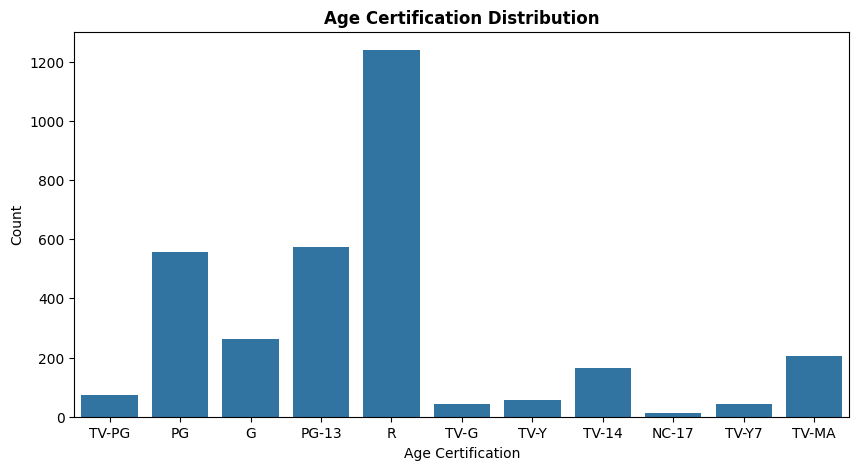

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize = (10, 5))
sns.countplot(data = movies_tv_shows_df, x = 'age_certification')

plt.title('Age Certification Distribution', fontweight = 'bold')
plt.xlabel('Age Certification')
plt.ylabel('Count')

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was selected to compare the number of titles across different age certification categories. It makes it easy to identify which age certifications are most common in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- **R is the most common age certification**, with significantly more titles than the other categories.
- **PG, PG-13, G, and TV-MA** have considerably fewer titles compared with R-rated content.
- Some categories, such as **NC-17, TV-Y7**, and **TV-G**, have very few titles.
- The distribution shows that the dataset has a **strong concentration of R-rated content.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. This analysis can help Amazon Prime Video understand the age distribution of its content library and identify which audience segments have greater content availability.

- **Content Strategy**: Amazon Prime Video can maintain a balanced content library across different age groups.
- **Content Acquisition**: Underrepresented age categories can be considered when acquiring or producing new content.
- **Personalized Recommendations**: Age certification can help provide more suitable content recommendations to different users.

**Possible Negative Impact**:

The high concentration of R-rated content may limit the availability of suitable content for younger audiences and families. Expanding content across family-friendly certifications could help attract a broader audience.

#### Chart - 5

Percentage of movies vs Tv shows analysis

In [ ]:
# How many movies and tv shows in the dataset
movies_tv_shows_df['type'].value_counts()

,count
type,
MOVIE,7852
SHOW,1009


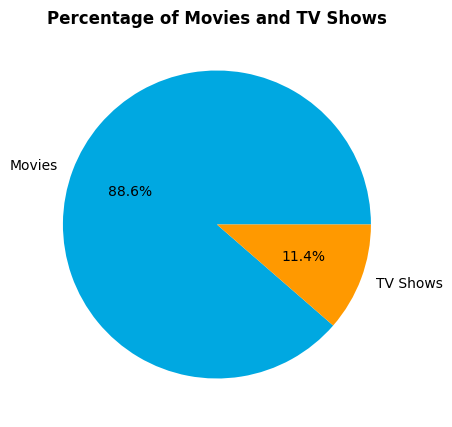

In [ ]:
# Chart - 5 visualization code

# percentage of movies and tv shows
type_counts = movies_tv_shows_df.drop_duplicates('id')['type'].value_counts()
total_movies = type_counts.get('MOVIE', 0)
total_tv_shows = type_counts.get('SHOW', 0)

plt.figure(figsize = (10,5))
plt.pie([total_movies, total_tv_shows], labels = ['Movies', 'TV Shows'], autopct = '%1.1f%%', colors=['#00A8E1', '#FF9900'])
plt.title('Percentage of Movies and TV Shows', fontweight = 'bold')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was selected to show the percentage contribution of Movies and TV Shows to the overall content library. It provides a clear and simple comparison of the proportion of each content type.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- Movies account for **88.7% of the total content**, making them the dominant content type.
- **TV Shows account for only 11.3%** of the total content library.
- The large difference indicates that the Amazon Prime content library is **strongly dominated by Movies.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. This insight can help Amazon Prime Video understand the current balance of its content library.

- **Content Strategy**: The platform can evaluate whether its current Movie-to-TV Show ratio matches user preferences.
- **Content Acquisition**: The relatively small share of TV Shows may indicate an opportunity to expand the TV Show catalog.
- **Audience Engagement**: Providing a better balance of Movies and TV Shows could help satisfy different viewing preferences.

**Possible Negative Impact**:

The low proportion of TV Shows may limit choices for users who prefer episodic content. Expanding the TV Show catalog with high-quality and engaging content could help attract and retain more users.

#### Chart - 6

TMDb Score Distribution

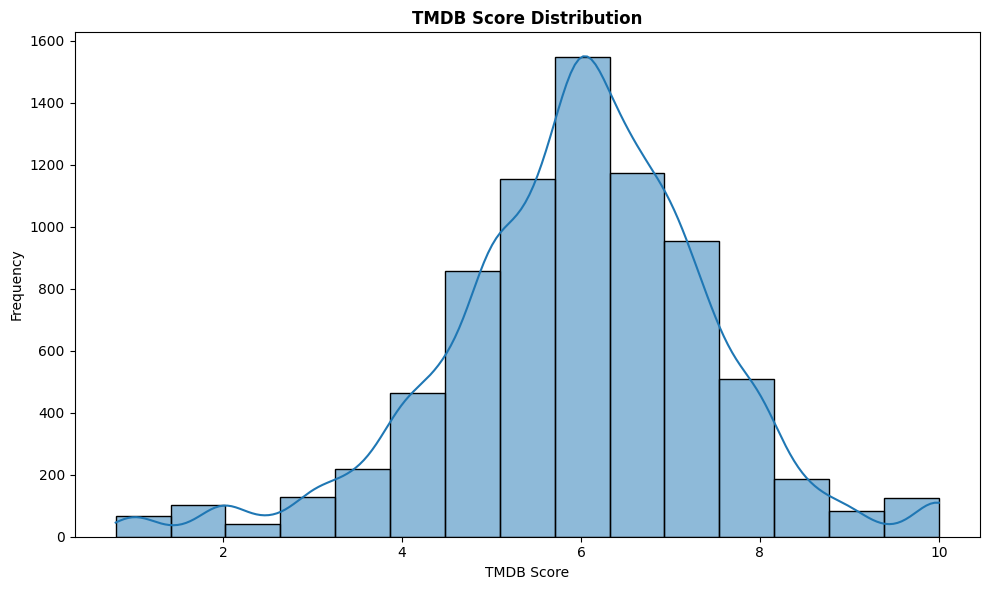

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 6))

sns.histplot(movies_tv_shows_df['tmdb_score'], bins=15, kde=True)

plt.title('TMDB Score Distribution', fontweight = 'bold')
plt.xlabel('TMDB Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was selected to understand the distribution of TMDB scores across the content library. It shows how frequently different score ranges occur and helps identify where most of the titles are concentrated.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- Most TMDB scores are concentrated around **5 to 7**.
- The highest concentration of titles is around a **TMDB score of approximately 6**.
- Very low and very high scores have comparatively fewer titles.
- The distribution indicates that most content has **moderate to good TMDB ratings.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. TMDB score distribution can help Amazon Prime Video understand the overall audience reception of its content.

- **Content Quality**: Helps identify the general quality level of the content library.
- **Content Acquisition**: Highly rated content can be considered when making future acquisition decisions.
- **Content Recommendations**: Ratings can be used as one factor in recommending better-performing content to users.

**Possible Negative Impact**:

If a large portion of the content receives only moderate or low ratings, it may indicate opportunities to improve content quality. Relying only on ratings for content decisions could also overlook other factors such as audience preferences, genre, and popularity.

#### Chart - 7

Top 10 Genres

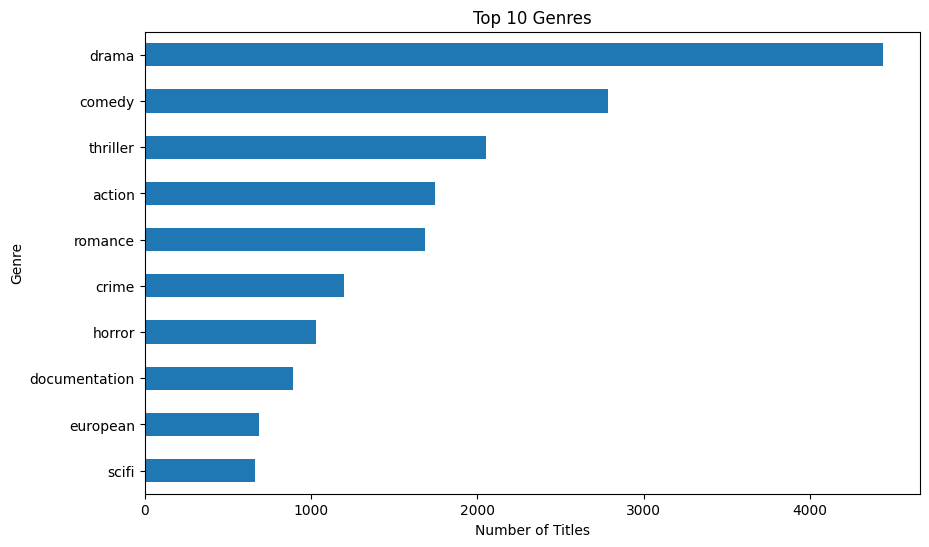

In [ ]:
# Chart - 7 visualization code

genre_df = movies_tv_shows_df.copy()
genre_df['genres'] = genre_df['genres'].str.strip('[]').str.replace("'", "")

genre_df = genre_df.assign(
    genres=genre_df['genres'].str.split(',')
).explode('genres')
genre_df['genres'] = genre_df['genres'].str.strip()

plt.figure(figsize=(10,6))
genre_df['genres'].value_counts().head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected to compare the number of titles across different genres. It makes it easy to identify and rank the most popular genres based on the number of titles available.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- **Drama is the most common genre**, with the highest number of titles in the dataset.
- **Comedy is the second most common genre**, followed by Thriller and Action.
- **Romance and Crime** also have a significant number of titles.
- **Sci-fi is the least common genre among the Top 10 genres** shown in the chart.
- Overall, the content library has a strong representation of **Drama, Comedy, Thriller, and Action** genres.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. Genre distribution can help Amazon Prime Video understand which types of content are most widely represented in its library.

- **Content Strategy**: The popularity of Drama and Comedy can help guide future content planning.
- **Content Acquisition**: Amazon Prime Video can identify opportunities to expand less-represented but potentially valuable genres.
- **Personalized Recommendations**: Genre information can be used to recommend content based on users' viewing preferences.
- **Audience Targeting**: Understanding genre distribution can help create more targeted marketing campaigns.

**Possible Negative Impact**:

If the platform focuses too heavily on a few popular genres, the content library may become less diverse. Maintaining a balance between popular and less-represented genres can help serve a wider range of audience preferences.

#### Chart - 8

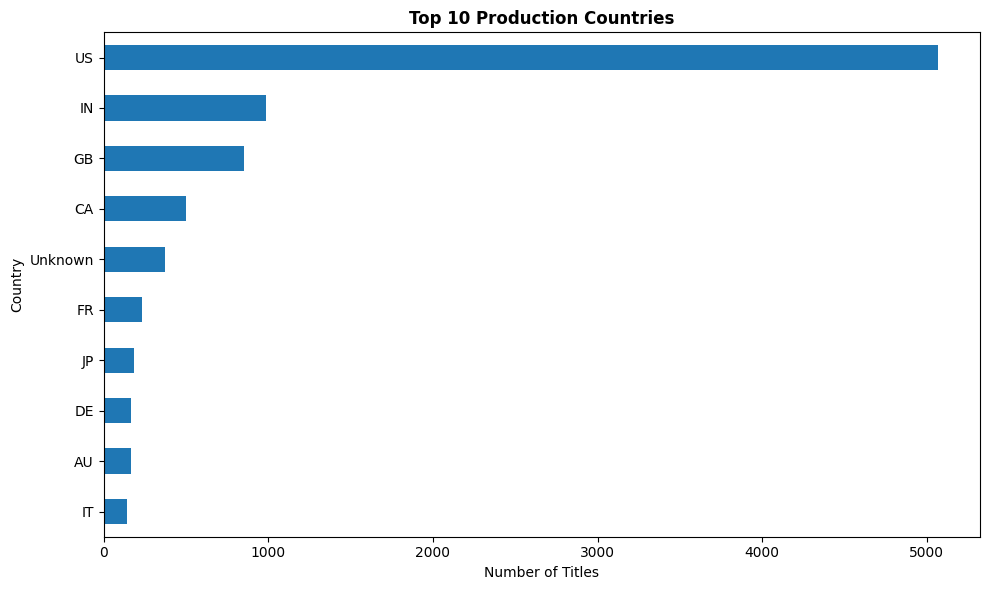

In [ ]:
# Chart - 8 visualization code

# Keep one record for each title
country_df = movies_tv_shows_df[['id', 'production_countries']].drop_duplicates('id')

# Split multiple countries into separate rows
country_df['production_countries'] = (
    country_df['production_countries']
    .str.strip('[]')
    .str.replace("'", "")
    .str.split(',')
)

country_df = country_df.explode('production_countries')

# Remove extra spaces
country_df['production_countries'] = country_df['production_countries'].str.strip()

# Replace blank values with Unknown
country_df['production_countries'] = country_df['production_countries'].replace('', 'Unknown')

# Get top 10 countries
top_countries = country_df['production_countries'].value_counts().head(10)

# Plot
plt.figure(figsize=(10,6))

top_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Production Countries', fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected to compare the number of titles produced by different countries. It makes it easy to rank the top production countries and compare their contribution to the content library.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- **The United States (US) is the leading production country**, with a significantly higher number of titles than the other countries.
- **India (IN) is the second-highest**, followed by the United Kingdom (GB) and Canada (CA).
- The remaining countries have considerably fewer titles compared with the US.
- **Unknown** appears among the top 10, indicating that production country information is unavailable for a notable number of titles.
- Overall, the content library has **a strong representation of US-produced content.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. Production country analysis can help Amazon Prime Video understand the geographical distribution of its content library.

- **Global Content Strategy**: Helps identify countries that contribute significantly to the content library.
- **Content Acquisition**: Amazon Prime Video can explore opportunities to acquire more content from underrepresented regions.
- **Regional Expansion**: Strong representation from countries such as the US and India can help support regional audience strategies.
- **Content Diversity**: Expanding content from different countries can improve cultural diversity and attract international audiences.

**Possible Negative Impact**:

Heavy dependence on content from a small number of countries may reduce geographical diversity. Increasing content from underrepresented regions could help Amazon Prime Video reach a broader international audience.

#### Chart - 9

Top 10 IMDb Rated Titles

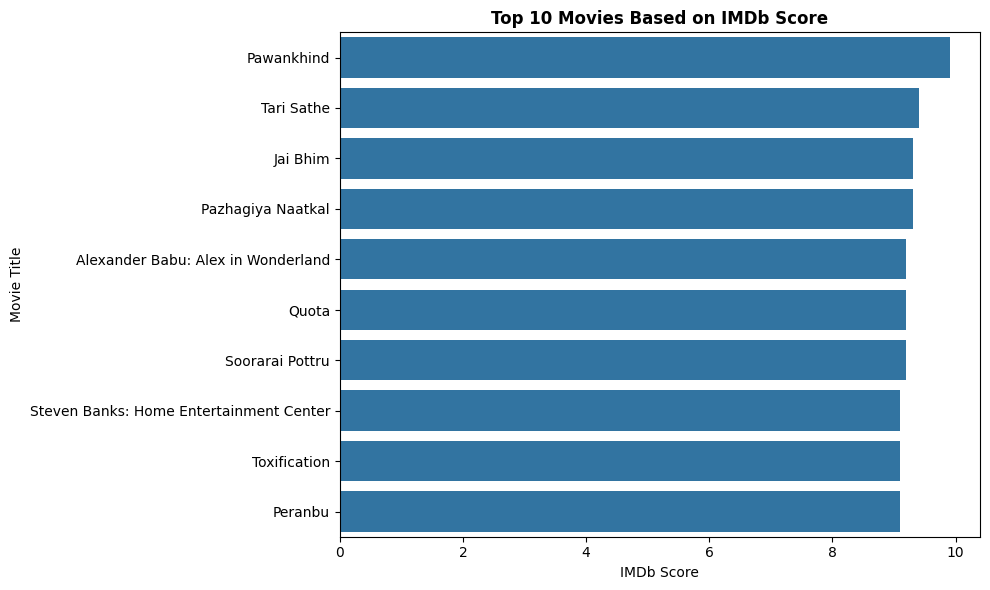

In [ ]:
# Chart - 9 visualization code

# Select only movies and keep one record per title
top_movies = movies_tv_shows_df[movies_tv_shows_df['type'] == 'MOVIE'].drop_duplicates('id')

# Get top 10 movies based on IMDb score
top_movies = top_movies.sort_values(
    by='imdb_score',
    ascending=False
).head(10)

# Create the chart
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_movies,
    x='imdb_score',
    y='title'
)

plt.title('Top 10 Movies Based on IMDb Score', fontweight='bold')
plt.xlabel('IMDb Score')
plt.ylabel('Movie Title')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected to compare the IMDb scores of the top 10 movies. It makes it easy to rank the movies and visually compare their ratings.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- **Pawankhind has the highest IMDb** score among the top 10 movies, with a score of approximately **9.9**.
- **Tari Sathe** and **Jai Bhim** also have very high IMDb scores of above **9.0**.
- All the movies shown in the Top 10 have **IMDb scores above 9.0**, indicating very strong audience ratings.
- The difference between the scores of the top-ranked movies is relatively small, showing that the Top 10 movies are all highly rated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. Identifying highly rated movies can help Amazon Prime Video understand which content receives strong audience appreciation.

- **Content Promotion**: Highly rated movies can be highlighted in promotional campaigns.
- **Content Recommendations**: These movies can be recommended to users looking for highly rated content.
- **Content Acquisition**: Similar highly rated movies can be considered when making future content acquisition decisions.
- **Audience Engagement**: Promoting well-rated content can increase viewing and user satisfaction.

**Possible Negative Impact**:

The analysis is based only on IMDb scores. A high rating does not necessarily mean that a movie will have high viewership. Therefore, IMDb score should be considered along with other factors such as popularity, votes, genre, and audience engagement.

#### Chart - 10

IMDb Score vs Runtime

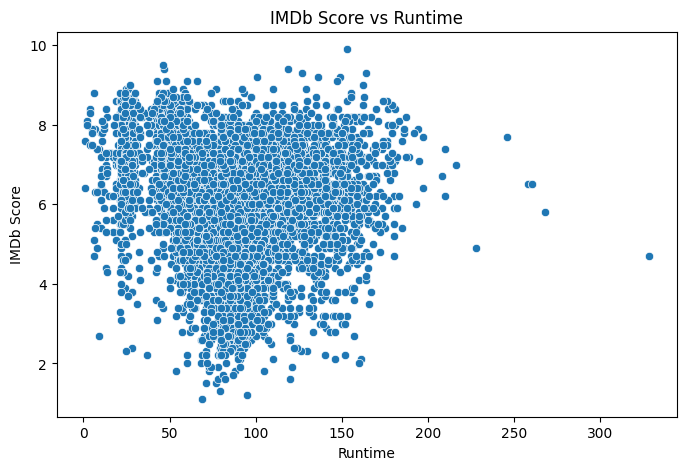

In [ ]:
# Chart - 10 visualization code

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=movies_tv_shows_df,
    x='runtime',
    y='imdb_score'
)

plt.title('IMDb Score vs Runtime')
plt.xlabel('Runtime')
plt.ylabel('IMDb Score')

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was selected to analyze the relationship between movie/show runtime and IMDb scores. Each point represents a title, allowing us to observe whether runtime has any noticeable relationship with IMDb ratings.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- Most titles have a runtime between approximately **50 and 180 minutes**.
- Most IMDb scores are concentrated between approximately **4 and 8**.
- The points are widely scattered, indicating **no strong relationship** between runtime and IMDb score.
- Some titles have unusually high runtimes, including a few titles above **200 minutes**, but their IMDb scores are not consistently higher.
- Therefore, **a longer runtime does not necessarily result in a higher IMDb score.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes. This analysis can help Amazon Prime Video understand whether content length is associated with audience ratings.

- **Content Planning**: Amazon Prime Video can avoid assuming that longer content automatically receives better ratings.
- **Content Strategy**: Producers can focus more on content quality rather than simply increasing runtime.
- **Audience Experience**: Understanding the relationship between runtime and ratings can help in creating content with suitable durations.
- **Content Recommendations**: Runtime can be considered along with ratings and other factors when recommending content to users.

**Possible Negative Impact**:

There is no major negative business insight from this chart. However, runtime alone cannot explain IMDb scores because ratings can also be influenced by **genre, storyline, cast, popularity, and audience preferences.**

**Conclusion**

Overall, the chart suggests that **IMDb score and runtime do not have a strong visible relationship** in this dataset. Therefore, content quality and other characteristics may be more important than runtime when determining audience ratings.

#### Chart - 11

IMDb Score by Content Type

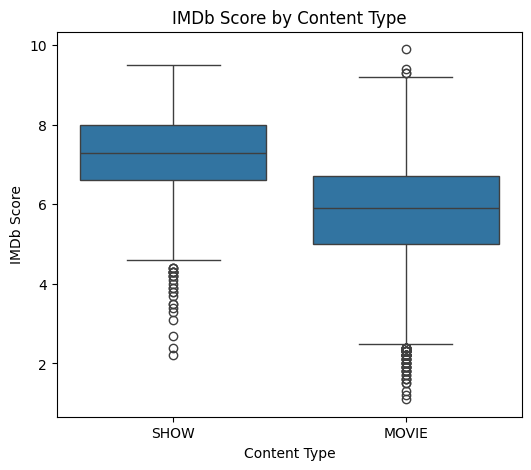

In [ ]:
# Chart - 11 visualization code

plt.figure(figsize=(6,5))

sns.boxplot(
    data=movies_tv_shows_df,
    x='type',
    y='imdb_score'
)

plt.title('IMDb Score by Content Type')
plt.xlabel('Content Type')
plt.ylabel('IMDb Score')

plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen to compare the distribution of IMDb scores between **Movies and TV Shows.**

It helps to understand the **median IMDb score, overall spread, and outliers** for both content types. This makes it easier to identify which type of content generally receives higher IMDb ratings.

**In summary**: A box plot is suitable because it provides a clear comparison of IMDb score distributions between Movies and TV Shows and highlights differences in ratings and unusual values.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- **TV Shows have a higher median IMDb score** than Movies.
- The median IMDb score for TV Shows is approximately **7.2**, while Movies have a median of around **6.0**.
- TV Shows generally have a **higher concentration of ratings around 6–8.**
- Movies show a **wider range of IMDb scores** and have more visible low-score and high-score outliers.
- The presence of outliers indicates that some Movies and TV Shows have exceptionally high or low IMDb scores compared with their respective distributions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

Yes, these insights can help Amazon Prime Video make better content-related decisions.

- **Content Strategy**: Since TV Shows have a higher median IMDb score, Amazon Prime Video can consider investing more in high-quality TV series.
- **Content Acquisition**: The platform can use rating patterns to identify and acquire content that is more likely to receive positive audience feedback.
- **Personalized Recommendations**: IMDb score distributions can support recommendation systems by helping promote highly rated content.
- **Marketing Strategy**: Highly rated TV Shows can be highlighted in promotional campaigns to increase viewer engagement and retention.
- **Quality Improvement**: Understanding why some movies receive lower ratings can help improve future content selection and production decisions.

**Insights that may lead to negative growth**:

There is no direct negative business impact shown by this chart. However, if Movies consistently receive lower ratings than TV Shows, relying heavily on low-rated movie content could potentially reduce viewer satisfaction and engagement.

**Conclusion**:

Overall, the chart indicates that **TV Shows generally receive higher IMDb ratings than Movies**. This insight can help Amazon Prime Video strengthen its content strategy, improve recommendations, and focus on content that is more likely to satisfy viewers.

#### Chart - 12

IMDb Score by Top Genres

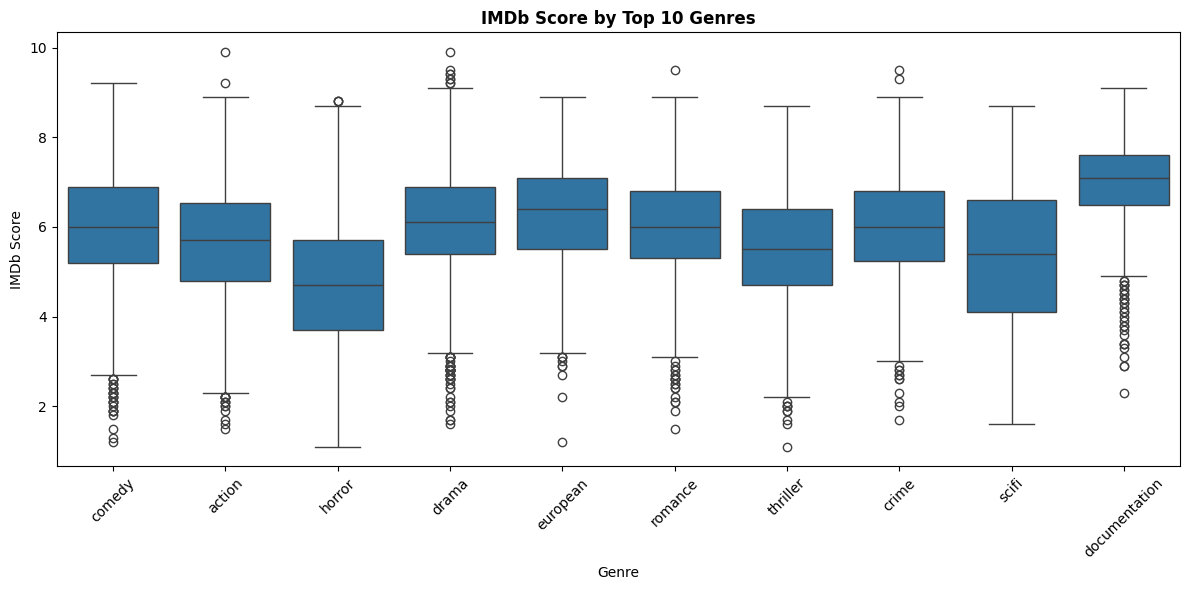

In [ ]:
# Chart - 12 visualization code

# Create a copy
genre_df = movies_tv_shows_df[['id', 'genres', 'imdb_score']].copy()

# Clean genres
genre_df['genres'] = (
    genre_df['genres']
    .str.strip('[]')
    .str.replace("'", "", regex=False)
    .str.split(',')
)

# Split multiple genres into separate rows
genre_df = genre_df.explode('genres').reset_index(drop=True)

# Remove extra spaces
genre_df['genres'] = genre_df['genres'].str.strip()

# Make sure IMDb score is numeric
genre_df['imdb_score'] = pd.to_numeric(
    genre_df['imdb_score'],
    errors='coerce'
)

# Get top 10 genres
top_genres = genre_df['genres'].value_counts().head(10).index

# Create boxplot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=genre_df[genre_df['genres'].isin(top_genres)],
    x='genres',
    y='imdb_score'
)

plt.xticks(rotation=45)
plt.title('IMDb Score by Top 10 Genres', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('IMDb Score')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows the full distribution of IMDb scores within each genre (median, quartiles, spread, and outliers) rather than just an average — making it easy to compare rating consistency across multiple genres side by side.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- Documentation has the highest median IMDb score at approximately 7.0, indicating the strongest typical rating among the top 10 genres.

- Horror has the lowest median IMDb score at approximately 4.8 and shows a relatively wide spread, indicating greater variation in ratings.

- European also has a relatively high median IMDb score of approximately 6.4.

- Comedy, Drama, Romance, and Crime have median IMDb scores around 6.0, showing relatively similar typical ratings.

- All genres contain low-scoring outliers, indicating that each genre includes some poorly rated titles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

The analysis can help Amazon Prime identify genres with consistently higher IMDb ratings and genres with greater variation in content quality. Documentation and European content show relatively higher median ratings, which may indicate opportunities for further content analysis and investment.

**Potential Risk**:

Horror has the lowest median IMDb score and a relatively wide distribution of ratings. This suggests inconsistent content performance within the genre. Therefore, increasing the quantity of Horror content without maintaining quality could negatively affect overall audience satisfaction.

#### Chart - 13

Genre vs Content Type

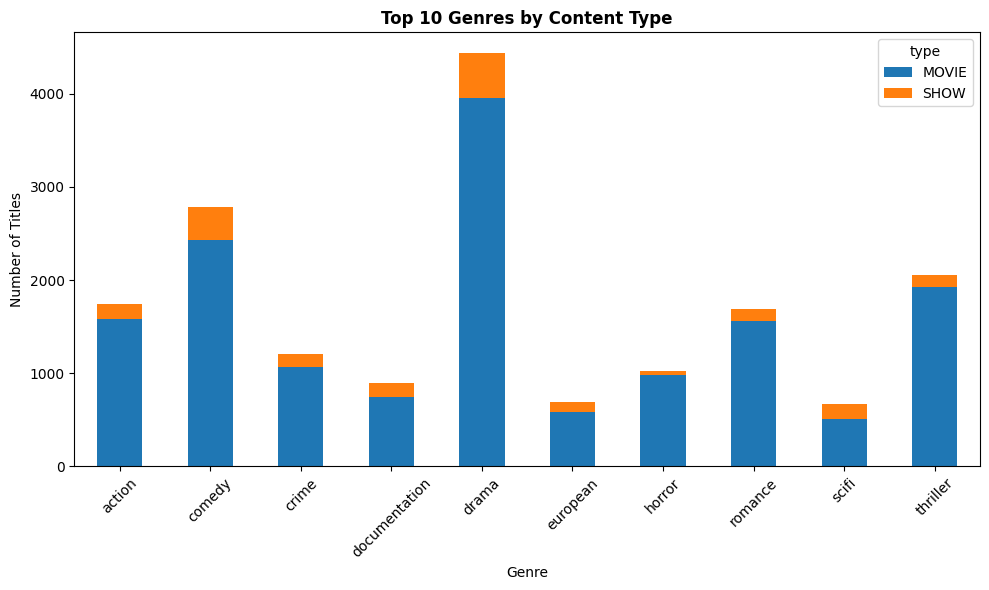

In [ ]:
# Chart - 13 visualization code

genre_type_df = movies_tv_shows_df[['id', 'genres', 'type']].drop_duplicates('id').copy()

# Clean genres
genre_type_df['genres'] = (
    genre_type_df['genres']
    .str.strip('[]')
    .str.replace("'", "", regex=False)
    .str.split(',')
)

# Split multiple genres
genre_type_df = genre_type_df.explode('genres').reset_index(drop=True)

# Remove extra spaces
genre_type_df['genres'] = genre_type_df['genres'].str.strip()

# Get top 10 genres
top_genres = genre_type_df['genres'].value_counts().head(10).index

# Filter top genres
genre_type_df = genre_type_df[
    genre_type_df['genres'].isin(top_genres)
]

# Create stacked bar chart
pd.crosstab(
    genre_type_df['genres'],
    genre_type_df['type']
).plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Top 10 Genres by Content Type', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart shows both the total volume of each genre and its composition (Movie vs. Show breakdown) in a single view — making it easy to see not just which genres are most common, but also how each genre splits across content types.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- Drama is the largest genre overall, with approximately 4,400 titles, and it also has the largest contribution from TV Shows.

- Comedy and Thriller are among the next most common genres, with Movies making up the majority of titles in both genres.

- Movies outnumber TV Shows across all of the top 10 genres shown in the chart.

- Drama, Comedy, and Romance have relatively large total volumes, making them important genres in the dataset.

- European, Sci-fi, and Documentation have comparatively lower title counts than the other major genres.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact**:

The analysis can help identify genres with high content volume and understand whether they are mainly represented by Movies or TV Shows. This can support content planning and help Amazon Prime identify opportunities for expanding TV Shows in genres that are currently dominated by Movies.

**Potential Risk**:

The strong dominance of Movies across the top genres may indicate an opportunity to improve the balance between Movies and TV Shows. However, this chart alone does not provide enough evidence to conclude that increasing TV Shows would directly improve subscriber retention or revenue.

#### Chart - 14 - Correlation Heatmap

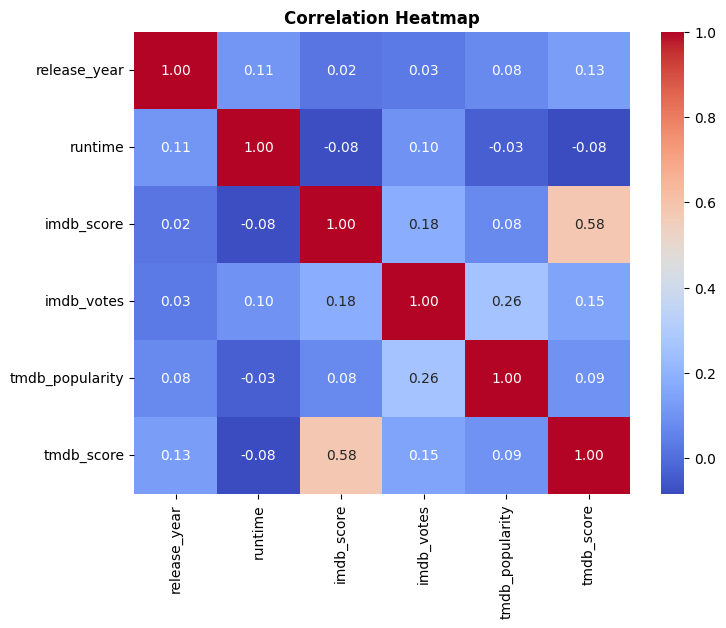

In [ ]:
# Correlation Heatmap visualization code

plt.figure(figsize=(8,6))

sns.heatmap(
    movies_tv_shows_df[
        [
            'release_year',
            'runtime',
            'imdb_score',
            'imdb_votes',
            'tmdb_popularity',
            'tmdb_score'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap', fontweight = 'bold')

plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the most efficient way to view the pairwise linear relationships between all numeric variables at once, using color intensity to instantly spot strong vs. weak relationships without checking each pair individually.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- IMDb score and TMDB score show the strongest relationship in the dataset, with a correlation of 0.58, indicating that the two rating platforms generally show similar rating patterns.

- IMDb votes and TMDB popularity have a mild positive correlation of 0.26, suggesting that more popular titles tend to receive more IMDb votes.

- IMDb score and IMDb votes show a weak positive correlation of 0.18, suggesting that highly rated titles do not necessarily receive substantially more votes.

- Runtime has very weak correlations with IMDb score (-0.08) and TMDB popularity (-0.03), suggesting little linear relationship between content length and these metrics.

- Release year has very weak correlations with the other variables, with all correlation values being 0.13 or lower. This suggests that newer content is not systematically rated better or worse than older content.

#### Chart - 15 - Pair Plot

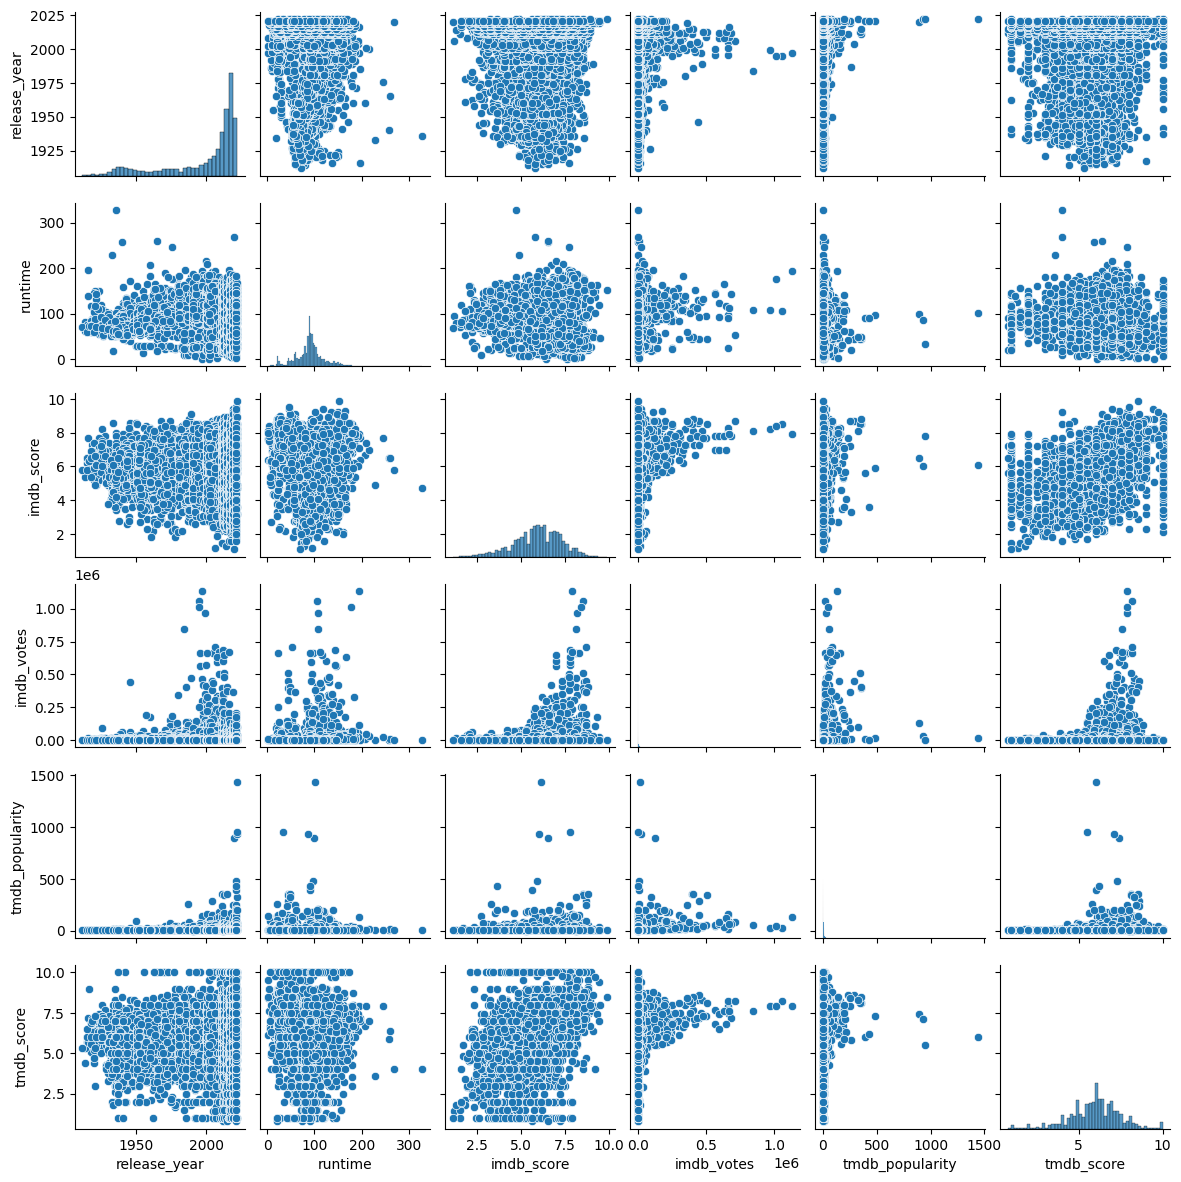

In [ ]:
# Chart - 15: Pair Plot of Numerical Variables

# Keep one record for each unique title
pairplot_df = movies_tv_shows_df.drop_duplicates('id')[
    [
        'release_year',
        'runtime',
        'imdb_score',
        'imdb_votes',
        'tmdb_popularity',
        'tmdb_score'
    ]
].dropna()

# Create pair plot
sns.pairplot(
    pairplot_df,
    diag_kind='hist',
    height=2.0
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot extends the correlation heatmap by visualizing the actual scatter relationship between every pair of numeric variables, along with each variable's individual distribution on the diagonal — showing patterns (linear, non-linear, clustered) that a single correlation number can hide.

##### 2. What is/are the insight(s) found from the chart?

Insights:

- **IMDb score vs. TMDB score** shows the clearest positive relationship among the variables, indicating that titles with higher IMDb scores generally tend to have higher TMDB scores.

- **IMDb score** distribution is roughly bell-shaped and centered around 6, while **release_year** is left-skewed, showing that most content in the dataset was released in recent years, with a longer tail toward older titles.

- **TMDB popularity** and **IMDb votes** are highly right-skewed, with most titles having relatively low values and a small number of titles having very high popularity or vote counts.

- **Runtime vs. IMDb score** shows a scattered cloud with no strong visible relationship, suggesting that runtime does not have a clear impact on IMDb score.

- A few **outliers** can be observed in variables such as runtime, IMDb votes, and TMDB popularity, indicating a small number of titles with unusually high values.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, the following recommendations can help Amazon Prime Video improve its content strategy, increase user engagement, and strengthen its content library:

**1. Increase TV Show Content**
- The analysis shows that **Movies account for around 88.7% of the content, while TV Shows account for only 11.3%.**
- Amazon Prime Video should consider increasing its **TV Show and series content** to create a better balance between movies and shows.
- More high-quality TV shows can encourage **long-term viewer engagement and regular platform usage.**

**2. Focus on Popular and High-Performing Genres**
- **Drama is the largest genre** in the dataset, followed by Comedy and Thriller.
- Amazon Prime Video should continue investing in **popular genres such as Drama, Comedy, Thriller, and Romance.**
- At the same time, the platform can explore less-represented genres to improve **content diversity** and attract niche audiences.

**3. Invest in High-Quality Content**
- **Documentation has the highest median IMDb score** among the top 10 genres, while **Horror has a comparatively lower median score.**
- The platform should focus on **quality rather than only increasing the quantity of content.**
- Genres with consistently better ratings can be considered for further content acquisition or original production.

**4. Use Ratings for Content Recommendations**
- The correlation analysis shows a **moderate positive relationship of 0.58 between IMDb Score and TMDB Score.**
- Amazon Prime Video can use rating-related information along with user preferences to improve **content recommendations and discovery.**
- Highlighting highly rated movies and shows can help users discover quality content more easily.

**5. Strengthen Regional and International Content**
- The analysis shows that the **United States is the leading production country**, followed by India, the United Kingdom, and Canada.
- Amazon Prime Video should continue expanding **regional and international content**, especially in markets with growing demand.
- Increasing content from different countries can help the platform attract a more **diverse global audience.**

**6. Maintain a Balanced Content Strategy**
- Movies strongly dominate the current content library, while shows represent a much smaller share.
- Therefore, Amazon Prime Video should maintain its strong movie library while gradually increasing **high-quality TV shows and diverse genres.**
- This balanced strategy can help the platform serve different viewer preferences and improve overall engagement.

# **Conclusion**

The analysis of Amazon Prime Video's content revealed key insights for improving platform growth. Movies dominate the content library, while Drama and Comedy are among the most popular genres. The US, India, and UK are the leading production countries. By increasing high-quality TV shows, promoting highly rated content, and improving content diversity, Amazon Prime can enhance user engagement and viewer satisfaction.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***